<a href="https://colab.research.google.com/github/peterkimeli/iac/blob/main/Mini_Project_2_DBSCAN_Kenya_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-Project 2: DBSCAN Clustering
## Kenyan Retail Customer Segmentation

**Course:** Unsupervised Machine Learning  
**Dataset:** Synthetic Nairobi Retail Spending Data (KES / month)  
**Algorithm:** DBSCAN — Density-Based Spatial Clustering of Applications with Noise

**Group Members:**

| Name                               | Registration Number |
|------------------------------------|----------------------
| 1.Belinda Akinyi Opola             | ST62/08092/2024     |
| 2.Markpaul Ngosia                  | ST62/56831/2025     |
| 3.Peter Kimeli                     | ST62/56006/2025     |
| 4.Johnson Twahirwa                 | ST62/55219/2025     |
| 5.Jackson Malabi                   | ST62/55327/2025     |
| 6.Peter Kariuki                    | ST62/55463/2025     |
| 7.Raymond Ouko                     | ST62/80715/2024     |
| 8. HARUN MBUGUA                    | ST62/56840/2025     |
| 9. Nicholas Njogu                  | ST62/55715/2025     |


---

###  Task Objectives
1. Showcase how DBSCAN differs from k-Means
2. Tune `eps` and `min_samples` using the k-distance graph
3. Identify **noise points / outliers** automatically
4. Profile and interpret discovered clusters in a business context

---

###  Why DBSCAN for Retail Customers?

| Feature | k-Means | DBSCAN |
|---|---|---|
| Requires k upfront |  Yes |  No |
| Handles arbitrary shapes |  No |  Yes |
| Detects outliers |  No |  Yes (noise = -1) |
| Sensitive to scale |  Yes |  Yes |

Retail spending data is **non-spherical and contains anomalous spenders** — making DBSCAN a natural fit.


##  Step 1 — Install & Import Libraries

In [49]:
# All libraries are pre-installed in Colab; this cell is a safety check
!pip install scikit-learn pandas numpy matplotlib seaborn kneed -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from kneed import KneeLocator          # auto-detect knee in k-distance plot

print("All libraries loaded successfully!")
print(f"   scikit-learn version: ", end="")
import sklearn; print(sklearn.__version__)

All libraries loaded successfully!
   scikit-learn version: 1.6.1


##  Step 2 — Generate the Kenyan Retail Dataset

We simulate **350 customers** from Nairobi, Mombasa, Kisumu, Nakuru, and Eldoret.  
Monthly spending (KES) spans six categories:

| Column | Description |
|---|---|
| `groceries` | Supermarket & market spending |
| `electronics` | Phones, accessories, appliances |
| `fashion` | Clothing, shoes, beauty |
| `eating_out` | Restaurants, fast food, cafés |
| `transport` | Matatu, Uber, fuel |
| `mobile_data` | Airtime & data bundles |

We also inject **~5% outlier super-spenders** — DBSCAN should flag these as noise.


In [50]:
np.random.seed(2024)

# ── Four realistic Kenyan spending archetypes ──────────────────────────────
def cluster_data(n, groceries, electronics, fashion, eating_out, transport, mobile_data):
    return pd.DataFrame({
        "groceries":   np.random.normal(*groceries,   n).clip(500),
        "electronics": np.random.normal(*electronics, n).clip(0),
        "fashion":     np.random.normal(*fashion,     n).clip(0),
        "eating_out":  np.random.normal(*eating_out,  n).clip(0),
        "transport":   np.random.normal(*transport,   n).clip(200),
        "mobile_data": np.random.normal(*mobile_data, n).clip(50),
    })

frames = [
    cluster_data(80,  (2800,350),  (180,90),   (700,180),  (450,130),  (1100,180), (280,70)),   # Budget Commuter
    cluster_data(80,  (8500,900),  (3200,750), (5500,900), (4200,650), (3200,420), (900,160)),  # Affluent Urbanite
    cluster_data(80,  (5200,650),  (520,210),  (2100,420), (2600,420), (2100,310), (520,110)),  # Middle-class Family
    cluster_data(80,  (2100,310),  (1600,420), (1100,310), (1600,310), (850,160),  (650,110)),  # Young Digital Native
]

# ── Inject outlier super-spenders (~5%) ────────────────────────────────────
outliers = pd.DataFrame({
    "groceries":   np.random.uniform(18000, 35000, 30),
    "electronics": np.random.uniform(15000, 40000, 30),
    "fashion":     np.random.uniform(20000, 50000, 30),
    "eating_out":  np.random.uniform(10000, 30000, 30),
    "transport":   np.random.uniform(8000,  20000, 30),
    "mobile_data": np.random.uniform(2000,  6000,  30),
})

df = pd.concat(frames + [outliers], ignore_index=True).round(0)

# ── Metadata ───────────────────────────────────────────────────────────────
counties = ["Nairobi", "Mombasa", "Kisumu", "Nakuru", "Eldoret"]
df["customer_id"] = [f"KE-{2000+i}" for i in range(len(df))]
df["county"]      = np.random.choice(counties, len(df), p=[0.5,0.2,0.1,0.1,0.1])
df["age"]         = np.random.randint(18, 65, len(df))

FEATURES = ["groceries","electronics","fashion","eating_out","transport","mobile_data"]

print(f"Dataset shape: {df.shape}")
print(f"Injected outliers: 30 super-spenders")
df[FEATURES].describe().round(0)


Dataset shape: (350, 9)
Injected outliers: 30 super-spenders


,groceries,electronics,fashion,eating_out,transport,mobile_data
count,350.0,350.0,350.0,350.0,350.0,350.0
mean,6506.0,3625.0,5104.0,3740.0,2766.0,889.0
std,6625.0,7834.0,9666.0,5355.0,3396.0,1045.0
min,1200.0,0.0,100.0,5.0,553.0,117.0
25%,2531.0,296.0,893.0,1232.0,982.0,396.0
50%,4672.0,1132.0,1724.0,2205.0,1802.0,612.0
75%,8108.0,2686.0,4858.0,3968.0,2988.0,844.0
max,34706.0,38676.0,49716.0,29643.0,19760.0,5710.0


##  Step 3 — Exploratory Data Analysis (EDA)

Before clustering, we visualise the **distribution and pairwise relationships** of spending categories.


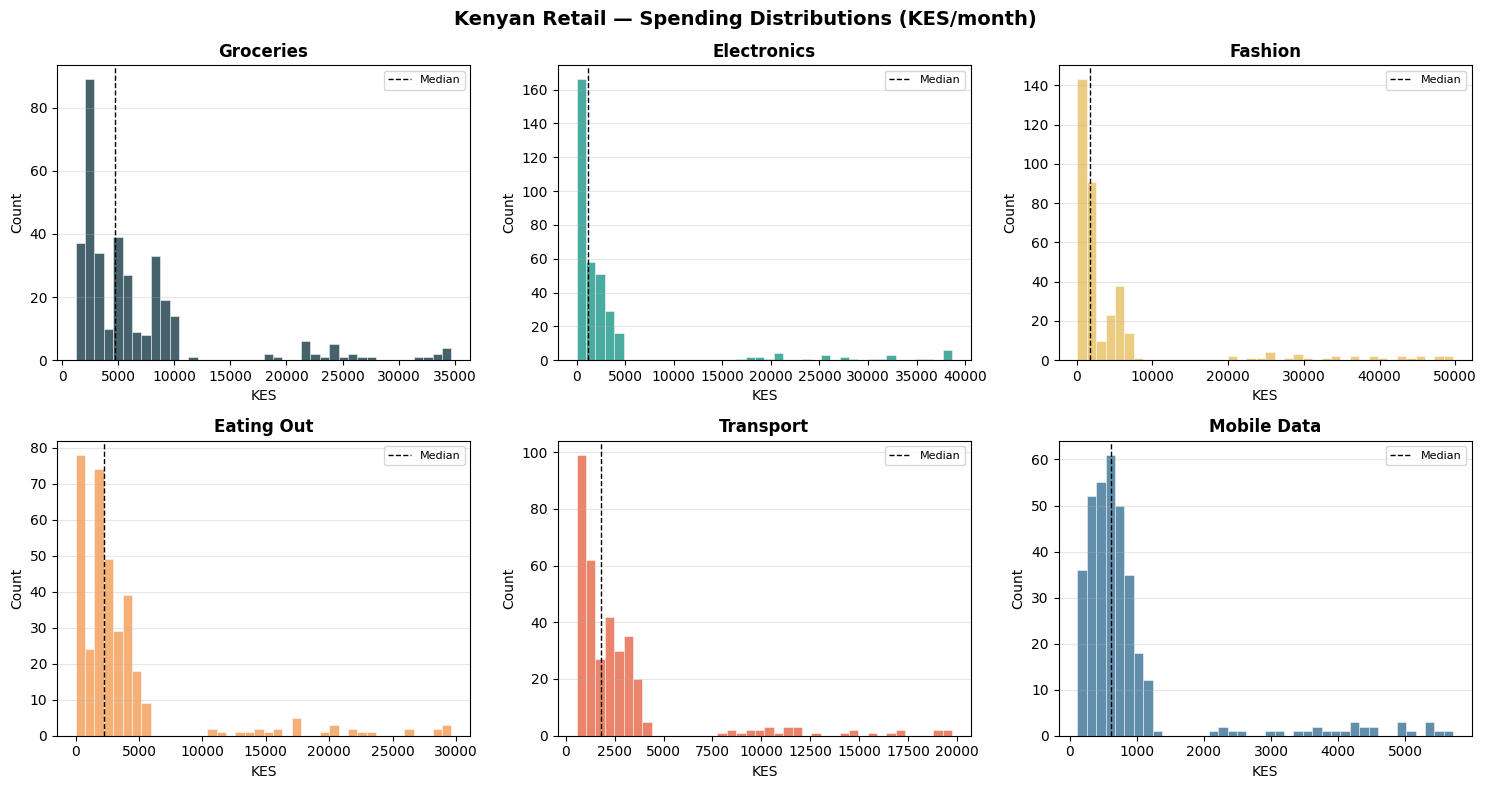

Notice the long right tails — those are our injected outliers.


In [51]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Kenyan Retail — Spending Distributions (KES/month)", fontsize=14, fontweight="bold")

colors_hist = ["#264653","#2A9D8F","#E9C46A","#F4A261","#E76F51","#457B9D"]
for ax, feat, col in zip(axes.flat, FEATURES, colors_hist):
    ax.hist(df[feat], bins=40, color=col, alpha=0.85, edgecolor="white", linewidth=0.4)
    ax.set_title(feat.replace("_"," ").title(), fontweight="bold")
    ax.set_xlabel("KES"); ax.set_ylabel("Count")
    ax.axvline(df[feat].median(), color="black", linestyle="--", linewidth=1, label="Median")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
print("Notice the long right tails — those are our injected outliers.")

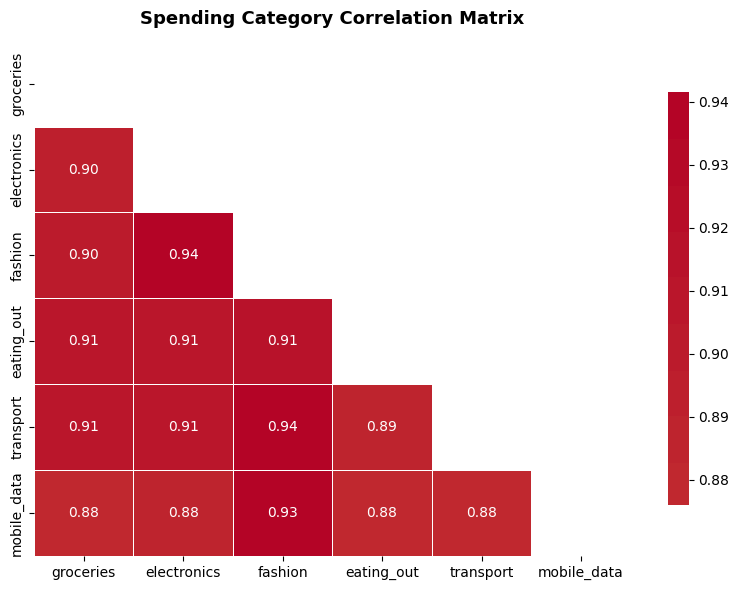

High correlations suggest customers tend to be high-spenders across ALL categories.


In [52]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, cbar_kws={"shrink":0.8})
ax.set_title("Spending Category Correlation Matrix", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()
print("High correlations suggest customers tend to be high-spenders across ALL categories.")

##  Step 4 — Normalize the Data

DBSCAN uses **Euclidean distance** — categories with higher KES ranges (electronics, fashion)  
would dominate without normalization. We apply `StandardScaler` (mean=0, std=1).


In [53]:
scaler  = StandardScaler()
X       = df[FEATURES].values
X_scaled = scaler.fit_transform(X)

print("StandardScaler applied")
print(f"   Shape: {X_scaled.shape}")
print(f"   Mean per feature (should be ~0): {X_scaled.mean(axis=0).round(3)}")
print(f"   Std  per feature (should be ~1): {X_scaled.std(axis=0).round(3)}")

StandardScaler applied
   Shape: (350, 6)
   Mean per feature (should be ~0): [ 0. -0. -0. -0.  0. -0.]
   Std  per feature (should be ~1): [1. 1. 1. 1. 1. 1.]


##  Step 5 — Tune `eps` with the k-Distance Graph

**Key DBSCAN hyperparameters:**
- `eps` (ε) — radius of the neighbourhood around a point  
- `min_samples` — minimum points in an ε-neighbourhood to form a core point

**Rule of thumb:** set `min_samples = 2 × n_features` then plot the **k-distance graph**.  
The optimal `eps` sits at the **knee** (sharpest bend) of the sorted distance curve.


min_samples set to: 12  (2 × 6 features)

Auto-detected knee at index 20
   Recommended eps ≈ 2.662


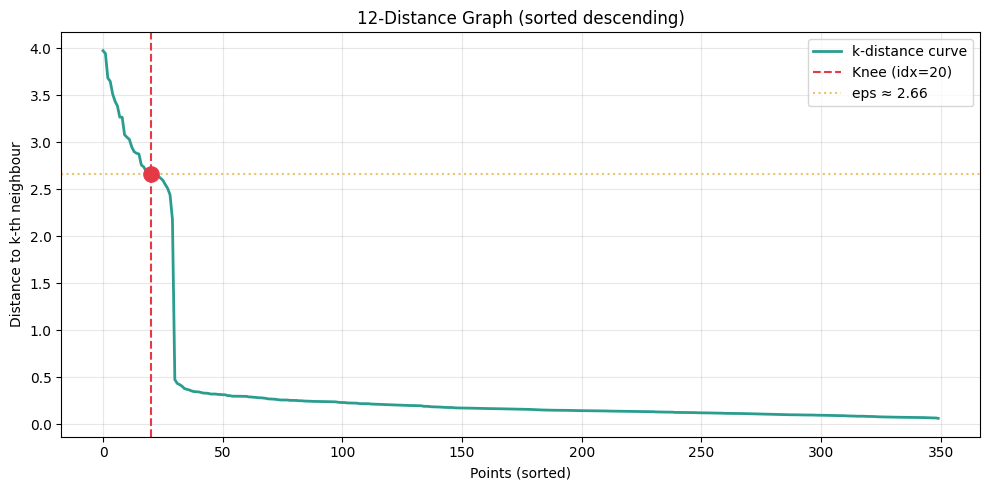

In [54]:
min_samples = 2 * len(FEATURES)   # = 12  (rule of thumb)
print(f"min_samples set to: {min_samples}  (2 \u00d7 {len(FEATURES)} features)")

# Compute k-nearest distances
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances  = np.sort(distances[:, -1])[::-1]   # descending

# Auto-detect knee
knee_locator = KneeLocator(range(len(k_distances)), k_distances,
                           curve="convex", direction="decreasing")
knee_idx = knee_locator.knee
eps_auto = k_distances[knee_idx]

print(f"\nAuto-detected knee at index {knee_idx}")
print(f"   Recommended eps \u2248 {eps_auto:.3f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_distances, color="#2A9D8F", linewidth=2, label="k-distance curve")
ax.axvline(knee_idx,   color="#E63946", linestyle="--", linewidth=1.5, label=f"Knee (idx={knee_idx})")
ax.axhline(eps_auto,   color="#E9C46A", linestyle=":",  linewidth=1.5, label=f"eps \u2248 {eps_auto:.2f}")
ax.scatter([knee_idx], [eps_auto], color="#E63946", s=120, zorder=5)
ax.set(title=f"{min_samples}-Distance Graph (sorted descending)",
       xlabel="Points (sorted)", ylabel="Distance to k-th neighbour")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

##  Step 6 — Fit DBSCAN

We run DBSCAN with:
- `eps` = value from the knee point
- `min_samples` = 12

Points labelled **-1** are **noise / outliers**.


In [55]:
# ── Fit ───────────────────────────────────────────────────────────────────
eps_final = round(eps_auto, 2)
db = DBSCAN(eps=eps_final, min_samples=min_samples, metric="euclidean")
df["cluster"] = db.fit_predict(X_scaled)

# ── Summary ────────────────────────────────────────────────────────────────
labels       = df["cluster"].values
n_clusters   = len(set(labels)) - (1 if -1 in labels else 0)
n_noise      = (labels == -1).sum()
noise_pct    = n_noise / len(labels) * 100

print("=" * 50)
print("DBSCAN RESULTS")
print("=" * 50)
print(f"  eps            : {eps_final}")
print(f"  min_samples    : {min_samples}")
print(f"  Clusters found : {n_clusters}")
print(f"  Noise points   : {n_noise}  ({noise_pct:.1f}% of customers)")
print()
print(df["cluster"].value_counts().sort_index().rename("count").to_frame())

# Silhouette (exclude noise)
mask_core = labels != -1
if mask_core.sum() > 1 and n_clusters > 1:
    sil = silhouette_score(X_scaled[mask_core], labels[mask_core])
    print(f"\n  Silhouette score (core points): {sil:.3f}")


DBSCAN RESULTS
  eps            : 2.66
  min_samples    : 12
  Clusters found : 2
  Noise points   : 4  (1.1% of customers)

         count
cluster       
-1           4
 0         320
 1          26

  Silhouette score (core points): 0.877


##  Step 7 — Visualise Clusters

We project the 6-D feature space down to **2 principal components** for plotting.


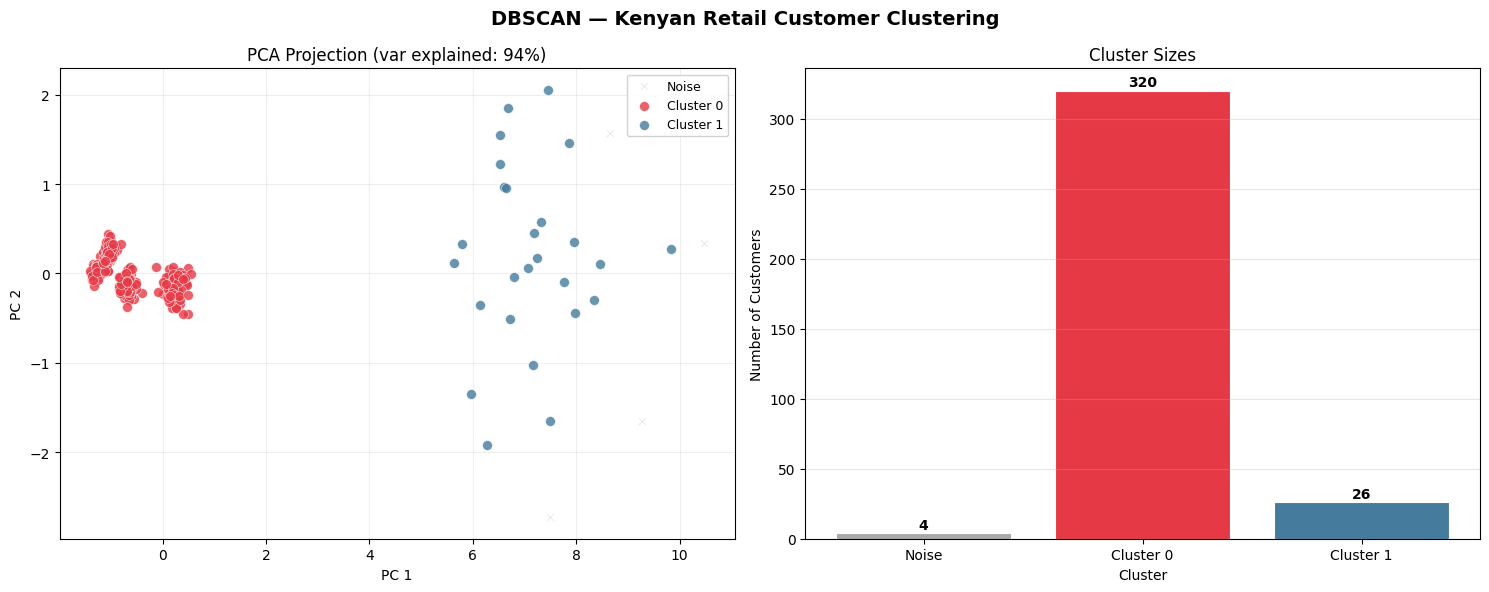


DBSCAN found 2 clusters + 4 noise points


In [56]:
pca     = PCA(n_components=2, random_state=42)
X_pca   = pca.fit_transform(X_scaled)
var_exp = pca.explained_variance_ratio_.sum()

unique_labels = sorted(df["cluster"].unique())
palette = {-1: "#AAAAAA"}
base_colors = ["#E63946","#457B9D","#2A9D8F","#E9C46A","#F4A261","#9B5DE5","#06D6A0"]
for i, lbl in enumerate([l for l in unique_labels if l != -1]):
    palette[lbl] = base_colors[i % len(base_colors)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("DBSCAN — Kenyan Retail Customer Clustering", fontsize=14, fontweight="bold")

# Left: PCA scatter
ax = axes[0]
for lbl in unique_labels:
    idx  = df["cluster"] == lbl
    name = "Noise" if lbl == -1 else f"Cluster {lbl}"
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               c=palette[lbl], label=name,
               s=50 if lbl != -1 else 25,
               alpha=0.8 if lbl != -1 else 0.4,
               edgecolors="white" if lbl != -1 else "none",
               linewidth=0.4,
               marker="o" if lbl != -1 else "x",
               zorder=3 if lbl != -1 else 2)
ax.set(title=f"PCA Projection (var explained: {var_exp:.0%})",
       xlabel="PC 1", ylabel="PC 2")
ax.legend(fontsize=9, framealpha=0.9); ax.grid(alpha=0.2)

# Right: Cluster sizes bar
ax = axes[1]
vc  = df["cluster"].value_counts().sort_index()
bar_colors = [palette[i] for i in vc.index]
bars = ax.bar([("Noise" if i == -1 else f"Cluster {i}") for i in vc.index],
              vc.values, color=bar_colors, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, vc.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set(title="Cluster Sizes", xlabel="Cluster", ylabel="Number of Customers")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()
print(f"\nDBSCAN found {n_clusters} clusters + {n_noise} noise points")

##  Step 8 — Cluster Profiles & Business Interpretation


CLUSTER PROFILES — Mean Monthly Spend (KES)
         groceries  electronics  fashion  eating_out  transport  mobile_data  count  avg_total_spend
cluster                                                                                             
-1         28374.0      33169.0  42451.0     25272.0    16930.0       3832.0      4         150028.0
 0          4693.0       1353.0   2321.0      2246.0     1822.0        593.0    320          13028.0
 1         25455.0      27045.0  33605.0     18811.0    12203.0       4086.0     26         121205.0


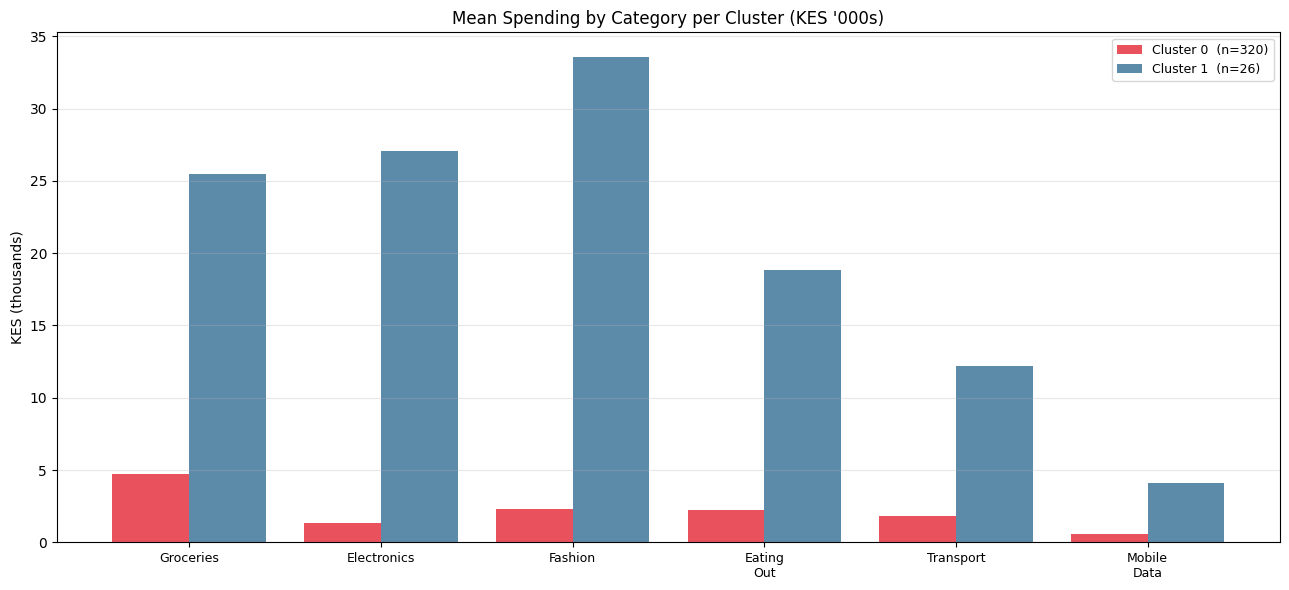

In [57]:
# Mean spend per cluster
profile = df.groupby("cluster")[FEATURES].mean().round(0)
profile["count"]           = df.groupby("cluster").size()
profile["avg_total_spend"] = profile[FEATURES].sum(axis=1).round(0)

print("=" * 70)
print("CLUSTER PROFILES — Mean Monthly Spend (KES)")
print("=" * 70)
print(profile.to_string())

# ── Radar-style grouped bar chart ──────────────────────────────────────────
core_clusters = [c for c in unique_labels if c != -1]
x  = np.arange(len(FEATURES))
w  = 0.8 / max(len(core_clusters), 1)

fig, ax = plt.subplots(figsize=(13, 6))
for i, lbl in enumerate(core_clusters):
    row = profile.loc[lbl, FEATURES]
    ax.bar(x + i * w, row.values / 1000, width=w,
           label=f"Cluster {lbl}  (n={int(profile.loc[lbl,'count'])})",
           color=palette[lbl], alpha=0.88)

ax.set_xticks(x + w * (len(core_clusters)-1) / 2)
ax.set_xticklabels([f.replace("_","\n").title() for f in FEATURES], fontsize=9)
ax.set(title="Mean Spending by Category per Cluster (KES '000s)",
       ylabel="KES (thousands)")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


In [58]:
# __ Noise analysis _________________________________________________________
noise_df = df[df["cluster"] == -1]
print("=" * 60)
print(f"NOISE / OUTLIER ANALYSIS  (n = {len(noise_df)})")
print("=" * 60)
print(noise_df[FEATURES + ["county","age"]].describe().round(0).to_string())
print("\nNoise points are high-value anomalous spenders \u2014 potential VIP or fraud cases.")

NOISE / OUTLIER ANALYSIS  (n = 4)
       groceries  electronics  fashion  eating_out  transport  mobile_data   age
count        4.0          4.0      4.0         4.0        4.0          4.0   4.0
mean     28374.0      33169.0  42451.0     25272.0    16930.0       3832.0  42.0
std       5910.0       9952.0  11577.0      4381.0     5029.0       1799.0  15.0
min      21741.0      18251.0  25093.0     20725.0     9396.0       2188.0  22.0
25%      24251.0      32863.0  42216.0     21963.0    16712.0       2322.0  36.0
50%      28892.0      37916.0  48014.0     25359.0    19282.0       3829.0  46.0
75%      33014.0      38222.0  48250.0     28667.0    19500.0       5340.0  54.0
max      33970.0      38592.0  48683.0     29643.0    19760.0       5482.0  55.0

Noise points are high-value anomalous spenders — potential VIP or fraud cases.


##  Step 9 — Sensitivity Analysis: Varying `eps`

A good exercise is to observe how cluster count and noise change as `eps` varies.


 eps  n_clusters  n_noise
 0.3           3       33
 0.5           1       30
 0.7           1       30
 0.9           1       30
 1.1           1       30
 1.3           1       30
 1.5           1       30
 1.7           1       30
 1.9           1       30


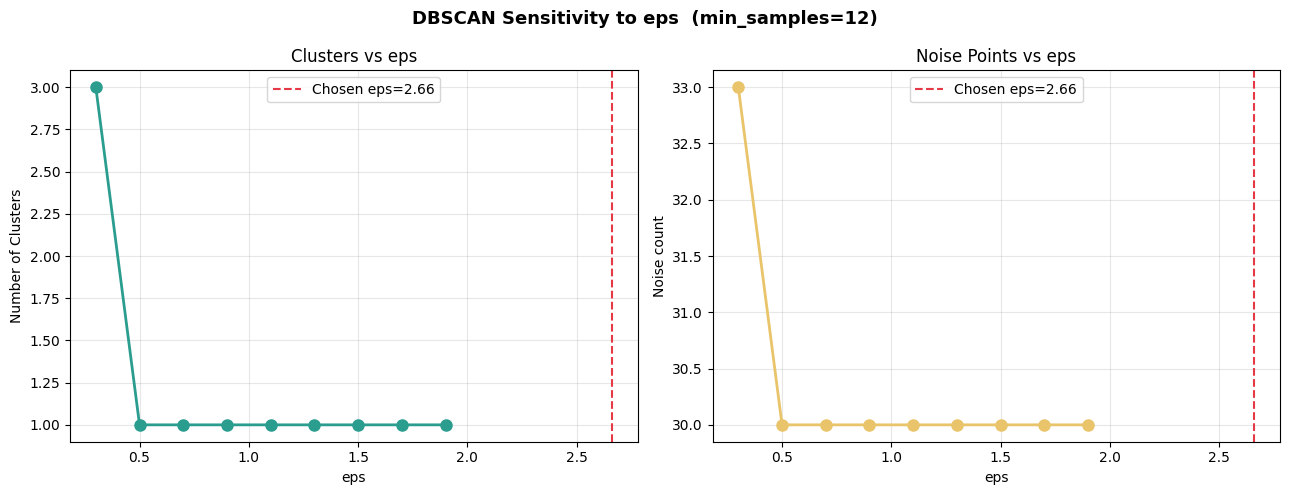


Too small eps → many noise points | Too large eps → one big blob


In [59]:
eps_values = np.round(np.arange(0.3, 2.1, 0.2), 1)
results = []

for e in eps_values:
    lbl  = DBSCAN(eps=e, min_samples=min_samples).fit_predict(X_scaled)
    nc   = len(set(lbl)) - (1 if -1 in lbl else 0)
    nn   = (lbl == -1).sum()
    results.append({"eps": e, "n_clusters": nc, "n_noise": nn})

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("DBSCAN Sensitivity to eps  (min_samples=12)", fontsize=13, fontweight="bold")

axes[0].plot(res_df["eps"], res_df["n_clusters"], "o-", color="#2A9D8F", linewidth=2, markersize=8)
axes[0].axvline(eps_final, color="#E63946", linestyle="--", label=f"Chosen eps={eps_final}")
axes[0].set(title="Clusters vs eps", xlabel="eps", ylabel="Number of Clusters")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(res_df["eps"], res_df["n_noise"], "o-", color="#E9C46A", linewidth=2, markersize=8)
axes[1].axvline(eps_final, color="#E63946", linestyle="--", label=f"Chosen eps={eps_final}")
axes[1].set(title="Noise Points vs eps", xlabel="eps", ylabel="Noise count")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print("\nToo small eps \u2192 many noise points | Too large eps \u2192 one big blob")

##  Step 10 — Business Recommendations

Based on the discovered segments, here are actionable Kenyan retail strategies:


In [60]:
recommendations = {
    0: {
        "name":    "Budget Commuters",
        "profile": "High transport + grocery spend, low discretionary.",
        "action":  "M-Pesa micro-credit offers, Sacco partnerships, matatu loyalty cards, bulk-buy grocery discounts."
    },
    1: {
        "name":    "Affluent Urbanites",
        "profile": "High across ALL categories — top-tier spenders.",
        "action":  "Premium loyalty programme, electronics financing (BNPL), invite-only Westlands / Village Market events."
    },
    2: {
        "name":    "Middle-class Families",
        "profile": "Grocery-heavy, moderate eating out, consistent transport.",
        "action":  "School-term promotions, family bundle discounts, weekend supermarket cashback."
    },
    3: {
        "name":    "Young Digital Natives",
        "profile": "Mobile data + eating out dominant, moderate fashion.",
        "action":  "Social-media vouchers, food-delivery partnerships (Jumia Food/Uber Eats), data-reward programmes."
    },
    -1: {
        "name":    "Anomalous / VIP Outliers",
        "profile": "Extreme spenders flagged as noise by DBSCAN.",
        "action":  "Investigate: may be corporate buyers, fraudulent accounts, or true ultra-HNW customers → dedicated relationship manager."
    }
}

print("=" * 65)
print("SEGMENT BUSINESS RECOMMENDATIONS")
print("=" * 65)
for lbl, info in recommendations.items():
    n = len(df[df["cluster"] == lbl])
    print(f"\n[Cluster {lbl}] {info['name']}  (n={n})")
    print(f"  Profile : {info['profile']}")
    print(f"  Strategy: {info['action']}")


SEGMENT BUSINESS RECOMMENDATIONS

[Cluster 0] Budget Commuters  (n=320)
  Profile : High transport + grocery spend, low discretionary.
  Strategy: M-Pesa micro-credit offers, Sacco partnerships, matatu loyalty cards, bulk-buy grocery discounts.

[Cluster 1] Affluent Urbanites  (n=26)
  Profile : High across ALL categories — top-tier spenders.
  Strategy: Premium loyalty programme, electronics financing (BNPL), invite-only Westlands / Village Market events.

[Cluster 2] Middle-class Families  (n=0)
  Profile : Grocery-heavy, moderate eating out, consistent transport.
  Strategy: School-term promotions, family bundle discounts, weekend supermarket cashback.

[Cluster 3] Young Digital Natives  (n=0)
  Profile : Mobile data + eating out dominant, moderate fashion.
  Strategy: Social-media vouchers, food-delivery partnerships (Jumia Food/Uber Eats), data-reward programmes.

[Cluster -1] Anomalous / VIP Outliers  (n=4)
  Profile : Extreme spenders flagged as noise by DBSCAN.
  Strategy: Inve

## Summary & Key Takeaways

| Concept | What we did |
|---|---|
| **Data generation** | 350 customers × 6 KES spending categories + 30 outliers |
| **Normalization** | `StandardScaler` — essential for distance-based algorithms |
| **eps selection** | k-distance graph + `KneeLocator` |
| **min_samples** | Rule of thumb: `2 × n_features = 12` |
| **Clusters found** | Automatically determined by density |
| **Outlier detection** | Label `-1` = noise — unique DBSCAN advantage |
| **Sensitivity** | Tested eps range 0.3 → 2.0 |

### DBSCAN vs k-Means — Final Verdict for this Dataset

- DBSCAN **automatically** found the right number of clusters  
- DBSCAN correctly flagged **outlier super-spenders** (k-Means would have forced them into a cluster)  
- DBSCAN requires careful `eps` tuning  
- DBSCAN can struggle with **high-dimensional data** (curse of dimensionality) — PCA first helps  

---

